# Actividad 3



Esta actividad consiste en la realización de la actividad evaluable número 3 asociada al bloque 3 de la asignatura. En ella, se deben desarrollar tareas de clasificación y regresión utilizando datos de alquileres vacacionales de AirBnB previamente trabajados y Máquinas de Vectores Soporte (SVM). Para llevar a cabo la actividad, he dividido el enunciado en varios experimentos, siendo:
- **Experimento 1:** El objetivo es clasificar el tipo de alojamiento (`room_type`) en función del resto de las características. Para ello, se deberá de construir un modelo de Clasificación utilizando `LinearSVC` y `SVC` (con parámetros por defecto).

- **Experimento 2:** Afinar el modelo `SVC` anterior ajustando los hiperparámetros usando el kernel RBF. Incluye:
    - Buscar los mejores valores para `γ` y `C` mediante `GridSearchCV`.
    - Realizar búsquedas refinadas: Dos búsquedas usando listas de parámetros generadas manualmente o con `numpy.logspace` para rangos amplios en escala logarítmica. Opcionalmente, para un tercer refinamiento, usar escala lineal.

- **Experimento 3:** Predecir el precio por noche (`price`) utilizando el resto de las características como variables independientes. Utilizar `LinearSVR` y `SVR` (con parámetros por defecto). Variantes de entrenamiento:
    - Usar todas las variables independientes.
    - Usar todas las variables excepto neighbourhood (por ser categórica y tener muchos valores).

- **Experimento 4:** Elegir el modelo con mejores resultados entre `LinearSVR` y `SVR` del experimento anterior y afinar hiperparámetros:
    - Solo C para `LinearSVR` (tres búsquedas).
    - γ y C para `SVR` (dos búsquedas).


## Importación de Librerías

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import LinearSVC, SVC, LinearSVR, SVR

## Carga de los Datos

Tal y como menciona el enunciado, los datos provienen de la web InsideAirbnb, dedicada al estudio de alquileres vacacionales ofrecidos en la plataforma Airbnb. El fichero es una versión editada de los datos de Madrid en abril de 2017.

Cargamos los datos y mostraremos una vista previa:

In [2]:
# Carga de datos
df = pd.read_csv('airbnb.csv')
df

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Centro,Justicia,40.424715,-3.698638,Entire home/apt,49,28,35,0.42,1,99
1,Centro,Embajadores,40.413418,-3.706838,Entire home/apt,80,5,18,0.30,1,188
2,Moncloa - Aravaca,Argüelles,40.424920,-3.713446,Entire home/apt,40,2,21,0.25,9,195
3,Moncloa - Aravaca,Casa de Campo,40.431027,-3.724586,Entire home/apt,55,2,3,0.13,9,334
4,Latina,Cármenes,40.403410,-3.740842,Private room,16,2,23,0.76,2,250
...,...,...,...,...,...,...,...,...,...,...,...
13316,Centro,Justicia,40.427500,-3.698354,Private room,14,1,0,0.00,1,10
13317,Chamberí,Gaztambide,40.431187,-3.711909,Entire home/apt,47,1,0,0.00,7,354
13318,Centro,Palacio,40.413552,-3.711461,Entire home/apt,60,2,0,0.00,1,17
13319,Centro,Universidad,40.425400,-3.709921,Entire home/apt,150,5,0,0.00,1,15


Esta es la descripción de cada una de las columnas:

| **Columna**                               | **Descripción**                                                                       |
|-------------------------------------------|---------------------------------------------------------------------------------------|
| neighbourhood_group                       | Agrupación de vecindario en la que se encuentra la propiedad.                         |
| neighbourhood                             | Nombre del vecindario de la propiedad (más exacto).                                   |
| latitude                                  | Latitud geográfica.                                                                   |
| longitude                                 | Longitud geográfica.                                                                  |
| room_type                                 | Tipo de habitación ofrecida (entera, privada, compartida).                            |
| price                                     | Precio por noche.                                                                     |
| minimum_nights                            | Número mínimo de noches requeridas para reservar.                                     |
| number_of_reviews                         | Cantidad total de reseñas.                                                            |
| reviews_per_month                         | Cantidad promedio de reseñas mensualmente.                                            |
| calculated_host_listings_count            | Número total de listados que posee el anfitrión en Airbnb.                            |
| availability_365                          | Número de días al año en que la propiedad está disponible para ser alquilada.         |



## Estudio Estadístico Inicial

Por brevedad, omito el Estudio Estadístico Inicial. Esto se realizó en la Actividad 1 de esta asignatura para los datos que estamos trabajando.

## Preprocesamiento de Datos

Lo realizaremos igual que en la Actividad 1.

En esta fase nos centraremos en limpiar, dividir y transformar el conjunto de datos, para obtener los datos de entrada necesarios para los modelos de Aprendizaje Automático.


### Eliminar Outliers

Eliminaremos los outliers máximos en las columnas `price` y `minimum_nights` detectadas en la fase de Estudio Estadístico para que los valores extremos no afecten negativamente al rendimiento del modelo:

In [3]:
df = df.drop(df['price'].idxmax())
df = df.drop(df['minimum_nights'].idxmax())
df.shape

(13319, 11)

No eliminaremos más outliers porque las demás variables no presentan desviaciones significativas según la información que tenemos y el conocimiento del dominio que disponemos.

### Dividir los datos en Conjunto de Entrenamiento y Test

Dividiremos los datos en conjunto de entrenamiento y test de manera que el conjunto de test sea un 20 % del total, tal y como lo solicita el enunciado. Para conservar una buena representación de las clases en esta división, haremos un muestreo estratificado basado en la columna `room_type`.

In [4]:
train_set, test_set = train_test_split(df, test_size = 0.2, stratify=df["room_type"], random_state = 0)

Comprobamos que efectivamente, las proporciones se mantienen en el `train_set` y `test_set`:

In [5]:
count_room_type_train = train_set["room_type"].value_counts().reset_index()
count_room_type_train.columns = ['room_type', 'count']
count_room_type_train['%'] = (count_room_type_train['count'] / count_room_type_train['count'].sum()) * 100
count_room_type_train

,room_type,count,%
0,Entire home/apt,6340,59.502581
1,Private room,4161,39.052088
2,Shared room,154,1.445331


In [6]:
count_room_type_test = test_set["room_type"].value_counts().reset_index()
count_room_type_test.columns = ['room_type', 'count']
count_room_type_test['%'] = (count_room_type_test['count'] / count_room_type_test['count'].sum()) * 100
count_room_type_test

,room_type,count,%
0,Entire home/apt,1585,59.496997
1,Private room,1041,39.076577
2,Shared room,38,1.426426


Dividimos los dataframes en `X` para variables (*features*) e `y` para la variable objetivo:

In [7]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'room_type'
y_train_set = train_set[['room_type']]

# DataFrame con todas las columnas excepto 'room_type'
X_train_set = train_set.drop(columns=['room_type'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'room_type'
y_test_set = test_set[['room_type']]

# DataFrame con todas las columnas excepto 'room_type'
X_test_set = test_set.drop(columns=['room_type'])

#### Pipeline de Preprocesamiento de Datos


El *pipeline* de procesamiento de datos incluye:
- **Tratamiento de variables categóricas**: he utilizado OneHotEncoder como mejor estrategia de codificación posible. He descartado OrdinalEncoder porque asignar un número a cada categoría introduce un sesgo, ya que en este caso no existe un orden entre las categorías.
- **Escalado**: utilizaremos el StandardScaler para normalizar los datos transformándolos a una distribución con media 0 y desviación estándar 1.

La variable objetivo `room_type` no necesita ser transformada.

Creamos los pipelines para la transformación de variables numéricas y categóricas. Y después, creamos el ColumnTrasnformer con todas ellas:

In [8]:
num_attribs = ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "neighbourhood"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

Revisamos que la transformación se ha realizado según lo esperado:

In [9]:
X_train_set_preprocessed

<10655x155 sparse matrix of type '<class 'numpy.float64'>'
	with 106550 stored elements in Compressed Sparse Row format>

In [10]:
X_train_set_preprocessed[:2].toarray()

array([[ 1.74614858,  0.16346946, -0.23798267,  0.2468434 , -0.56682293,
        -0.72360467,  1.08206011, -0.65924589,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

Es importante tener en cuenta que OneHotEncoder genera una gran cantidad de columnas o dimensiones, y esto incrementa el número de instancias necesarias para obtener un entrenamiento confiable. Estas son las columnas que tienen nuestros datos transformados:

In [11]:
# Nombres de las columnas
preprocessing.get_feature_names_out()

array(['num__latitude', 'num__longitude', 'num__price',
       'num__minimum_nights', 'num__number_of_reviews',
       'num__reviews_per_month', 'num__calculated_host_listings_count',
       'num__availability_365', 'cat__neighbourhood_group_Arganzuela',
       'cat__neighbourhood_group_Barajas',
       'cat__neighbourhood_group_Carabanchel',
       'cat__neighbourhood_group_Centro',
       'cat__neighbourhood_group_Chamartín',
       'cat__neighbourhood_group_Chamberí',
       'cat__neighbourhood_group_Ciudad Lineal',
       'cat__neighbourhood_group_Fuencarral - El Pardo',
       'cat__neighbourhood_group_Hortaleza',
       'cat__neighbourhood_group_Latina',
       'cat__neighbourhood_group_Moncloa - Aravaca',
       'cat__neighbourhood_group_Moratalaz',
       'cat__neighbourhood_group_Puente de Vallecas',
       'cat__neighbourhood_group_Retiro',
       'cat__neighbourhood_group_Salamanca',
       'cat__neighbourhood_group_San Blas - Canillejas',
       'cat__neighbourhood_group_Te

## Experimento 1

El objetivo es clasificar el tipo de alojamiento (`room_type`) en función del resto de las características. Para ello, se deberá de construir un modelo de Clasificación utilizando `LinearSVC` y `SVC` (con parámetros por defecto).

### LinearSVC


In [21]:
# Entrenar el modelo
model = LinearSVC(C=1, random_state=42) # C = 1 es el predeterminado
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

LinearSVC(C=1, random_state=42)

Accuracy: 0.79530736743313
                 precision    recall  f1-score   support

Entire home/apt       0.80      0.89      0.85      6340
   Private room       0.78      0.68      0.72      4161
    Shared room       0.12      0.01      0.01       154

       accuracy                           0.80     10655
      macro avg       0.57      0.53      0.53     10655
   weighted avg       0.78      0.80      0.79     10655



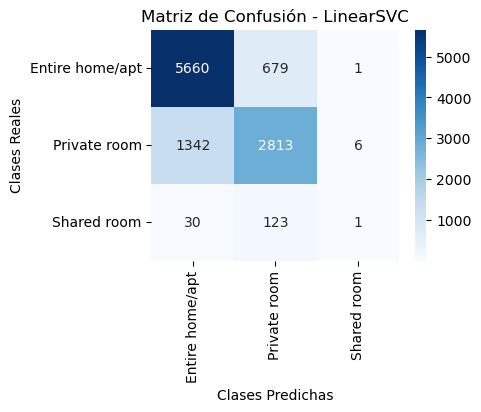

In [22]:
# Hacer predicciones con el conjunto de Entrenamiento
y_pred = model.predict(X_train_set_preprocessed)

# Evaluar el modelo
print("+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
print("Accuracy:", accuracy_score(y_train_set, y_pred))
print(classification_report(y_train_set, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_train_set, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.title('Matriz de Confusión - LinearSVC')
plt.show()

Accuracy: 0.7841591591591591
                 precision    recall  f1-score   support

Entire home/apt       0.80      0.87      0.84      1585
   Private room       0.75      0.68      0.71      1041
    Shared room       0.00      0.00      0.00        38

       accuracy                           0.78      2664
      macro avg       0.52      0.52      0.52      2664
   weighted avg       0.77      0.78      0.78      2664



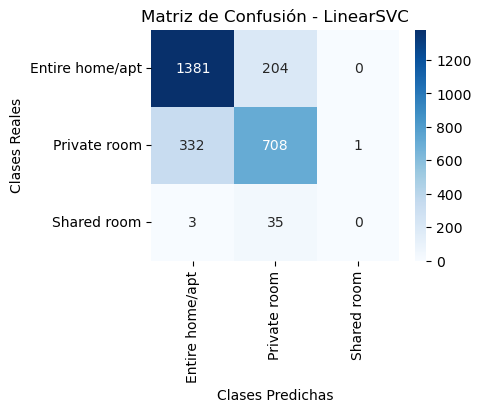

In [24]:
# Hacer predicciones con el conjunto de Test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluar el modelo
print("+++ RESULTADOS PARA EL CONJUNTO DE TEST +++")
print("Accuracy:", accuracy_score(y_test_set, y_pred))
print(classification_report(y_test_set, y_pred))

# Generar la matriz de confusión
conf_matrix = confusion_matrix(y_test_set, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.title('Matriz de Confusión - LinearSVC')
plt.show()

### SVC

In [26]:
# Entrenar el modelo
model = SVC(random_state=42, kernel='rbf', gamma='scale', C=1)  # Con parametros predeterminados
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

SVC(C=1, random_state=42)

Accuracy: 0.9053965274519005
                 precision    recall  f1-score   support

Entire home/apt       0.93      0.94      0.93      6340
   Private room       0.87      0.89      0.88      4161
    Shared room       0.00      0.00      0.00       154

       accuracy                           0.91     10655
      macro avg       0.60      0.61      0.60     10655
   weighted avg       0.89      0.91      0.90     10655



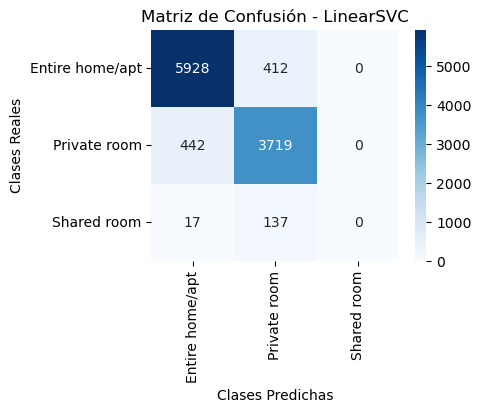

In [27]:
# Hacer predicciones en el conjunto de entrenamiento
y_pred = model.predict(X_train_set_preprocessed)

# Evaluar el modelo
print("+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
print("Accuracy:", accuracy_score(y_train_set, y_pred))
print(classification_report(y_train_set, y_pred, zero_division=0))

# Generar la matriz de confusión
conf_matrix = confusion_matrix(y_train_set, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.title('Matriz de Confusión - SVC')
plt.show()

Accuracy: 0.8862612612612613
                 precision    recall  f1-score   support

Entire home/apt       0.92      0.91      0.92      1585
   Private room       0.84      0.88      0.86      1041
    Shared room       0.00      0.00      0.00        38

       accuracy                           0.89      2664
      macro avg       0.59      0.60      0.59      2664
   weighted avg       0.87      0.89      0.88      2664



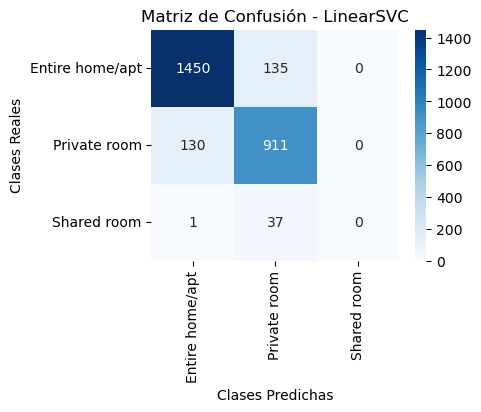

In [29]:
# Hacer predicciones en el conjunto de test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluar el modelo
print("+++ RESULTADOS PARA EL CONJUNTO DE TEST +++")
print("Accuracy:", accuracy_score(y_test_set, y_pred))
print(classification_report(y_test_set, y_pred, zero_division=0))

# Generar la matriz de confusión
conf_matrix = confusion_matrix(y_test_set, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.title('Matriz de Confusión - SVC')
plt.show()

### Conclusiones Experimento 1

Conclusiones generales tras revisar los resultados obtenidos:

- **LinearSVC**:
    - El modelo funciona bien para las clases dominantes (`Entire home/apt` y `Private room`), especialmente `Entire home/apt` con precisión (0.80) y recall (0.87). No hay signos de sobreajuste, ya que el rendimiento en el conjunto de prueba es consistente con el de entrenamiento.
    - El modelo tiene un rendimiento extremadamente pobre en la clase `Shared room`: precisión (0.12), recall (0.01), F1-score (0.01), debido a su bajo soporte (muy pocas instancias en comparación con las otras clases). Las métricas ponderadas (weighted avg) están infladas por las clases más frecuentes, ocultando el pobre rendimiento en `Shared room`.
    - Aunque hayamos hecho el muestreo estratificado para que el muestreo no impactara más en el desbalanceo de las clases, habría que considerar otras técnicas para manejar el desbalanceo, como realizar un sobremuestreo de la clase `Shared room` o un submuestreo de las clases dominantes, o utilizar una función de pérdida.

- **SVC**:
    - El modelo tiene un desempeño muy bueno en las clases dominantes (`Entire home/apt` y `Private room`), con alta precisión y recall. No hay evidencia de sobreajuste, ya que el rendimiento en el conjunto de prueba es consistente con el conjunto de entrenamiento.
    - El modelo tiene un desempeño desastroso en la clase `Shared room`: precisión (0.00), recall (0.00), F1-score (0.00), debido a su bajo soporte (solo 154 instancias en entrenamiento y 38 en prueba). Esto causa que las métricas macro promedio sean bajas: precisión (0.59), recall (0.60), F1-score (0.59).
    - La matriz de confusión muestra que las instancias de `Shared room` siempre son clasificadas como una de las clases dominantes.
    - Los motivos pueden ser:
        - Al igual que antes, que las clases están desbalanceadas, teniendo `Shared room` muy pocas instancias.
        - Las fronteras de decisión pueden ser difíciles, haciendo que las características de las instancias de Shared room no las separen bien de las otras clases en el espacio de características.
        - Los valores predeterminados se podrían afinar más.



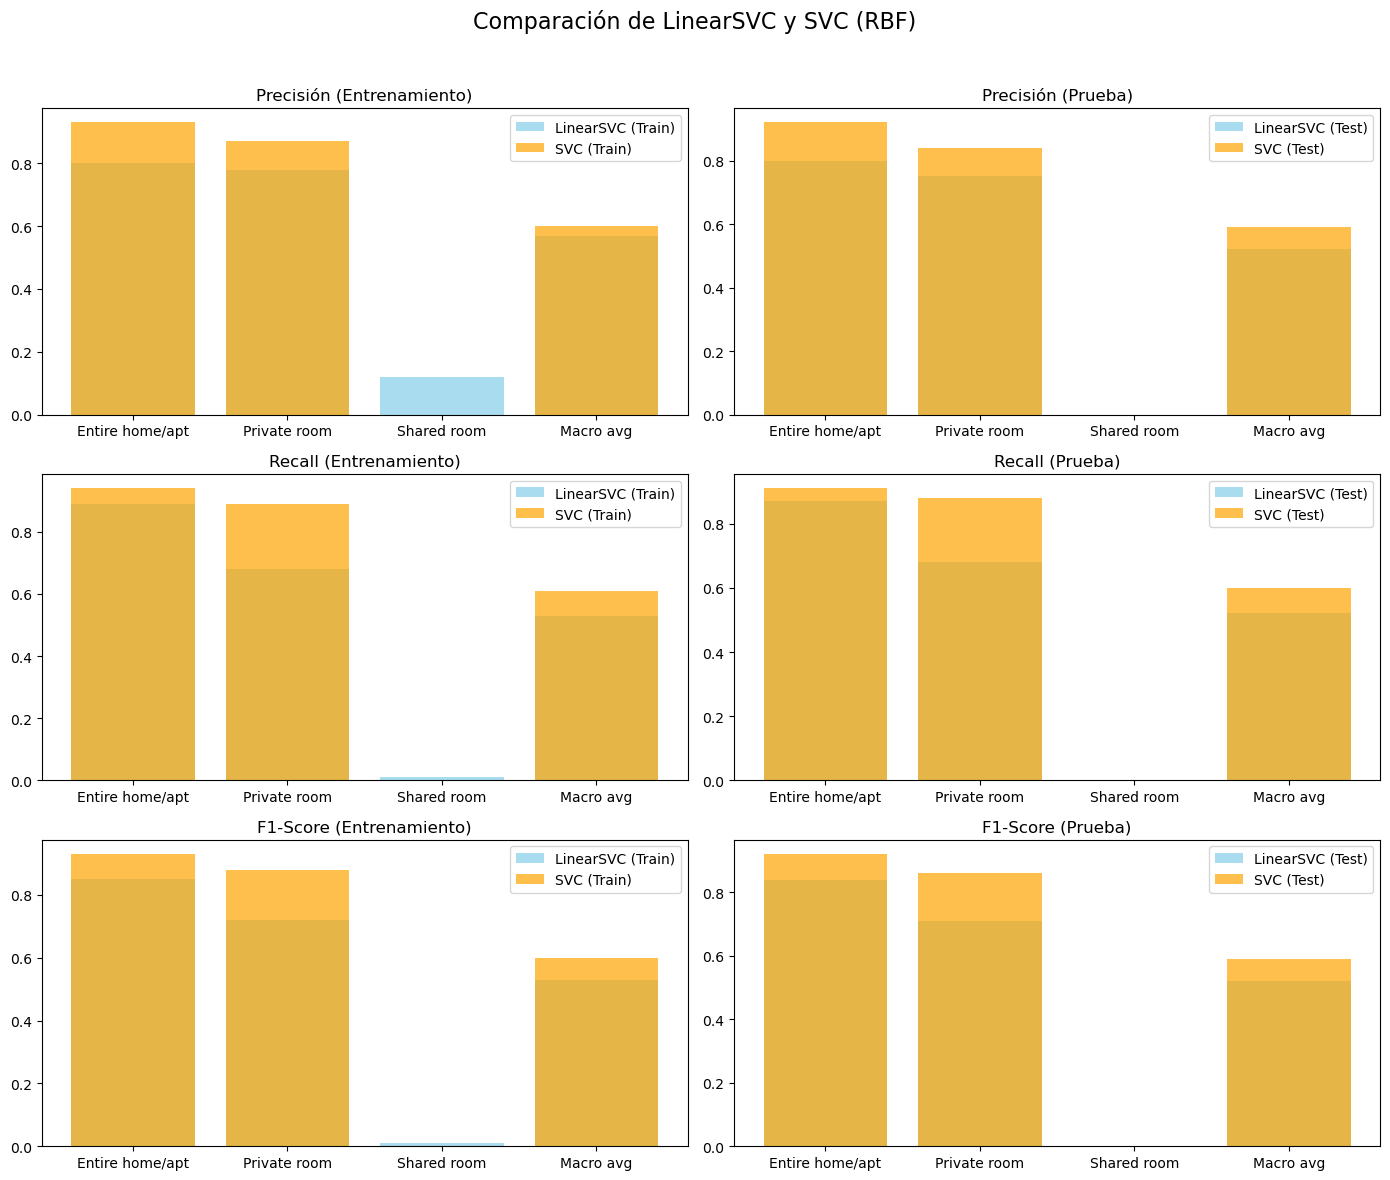

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Datos para graficar
categories = ['Entire home/apt', 'Private room', 'Shared room', 'Macro avg']
metrics = ['Precision', 'Recall', 'F1-Score']

# LinearSVC resultados
linear_svc_train = [0.80, 0.78, 0.12, 0.57]  # Precision
linear_svc_test = [0.80, 0.75, 0.00, 0.52]   # Precision

linear_svc_recall_train = [0.89, 0.68, 0.01, 0.53]  # Recall
linear_svc_recall_test = [0.87, 0.68, 0.00, 0.52]   # Recall

linear_svc_f1_train = [0.85, 0.72, 0.01, 0.53]  # F1
linear_svc_f1_test = [0.84, 0.71, 0.00, 0.52]   # F1

# SVC resultados
svc_train = [0.93, 0.87, 0.00, 0.60]  # Precision
svc_test = [0.92, 0.84, 0.00, 0.59]   # Precision

svc_recall_train = [0.94, 0.89, 0.00, 0.61]  # Recall
svc_recall_test = [0.91, 0.88, 0.00, 0.60]   # Recall

svc_f1_train = [0.93, 0.88, 0.00, 0.60]  # F1
svc_f1_test = [0.92, 0.86, 0.00, 0.59]   # F1

# Crear figuras para graficar
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Comparación de LinearSVC y SVC (RBF)', fontsize=16)

# Gráficos para precisión
axs[0, 0].bar(categories, linear_svc_train, color='skyblue', alpha=0.7, label='LinearSVC (Train)')
axs[0, 0].bar(categories, svc_train, color='orange', alpha=0.7, label='SVC (Train)')
axs[0, 0].set_title('Precisión (Entrenamiento)')
axs[0, 0].legend()

axs[0, 1].bar(categories, linear_svc_test, color='skyblue', alpha=0.7, label='LinearSVC (Test)')
axs[0, 1].bar(categories, svc_test, color='orange', alpha=0.7, label='SVC (Test)')
axs[0, 1].set_title('Precisión (Prueba)')
axs[0, 1].legend()

# Gráficos para recall
axs[1, 0].bar(categories, linear_svc_recall_train, color='skyblue', alpha=0.7, label='LinearSVC (Train)')
axs[1, 0].bar(categories, svc_recall_train, color='orange', alpha=0.7, label='SVC (Train)')
axs[1, 0].set_title('Recall (Entrenamiento)')
axs[1, 0].legend()

axs[1, 1].bar(categories, linear_svc_recall_test, color='skyblue', alpha=0.7, label='LinearSVC (Test)')
axs[1, 1].bar(categories, svc_recall_test, color='orange', alpha=0.7, label='SVC (Test)')
axs[1, 1].set_title('Recall (Prueba)')
axs[1, 1].legend()

# Gráficos para F1-Score
axs[2, 0].bar(categories, linear_svc_f1_train, color='skyblue', alpha=0.7, label='LinearSVC (Train)')
axs[2, 0].bar(categories, svc_f1_train, color='orange', alpha=0.7, label='SVC (Train)')
axs[2, 0].set_title('F1-Score (Entrenamiento)')
axs[2, 0].legend()

axs[2, 1].bar(categories, linear_svc_f1_test, color='skyblue', alpha=0.7, label='LinearSVC (Test)')
axs[2, 1].bar(categories, svc_f1_test, color='orange', alpha=0.7, label='SVC (Test)')
axs[2, 1].set_title('F1-Score (Prueba)')
axs[2, 1].legend()

# Ajustar espaciado
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Observaciones de los resultados de los gráficos:

- **Desempeño de SVC sobre LinearSVC**: En las clases principales (`Entire home/apt` y `Private room`), el modelo SVC tiene consistentemente mejores métricas. La clase `Shared room` es muy difícil de clasificar para ambos modelos. En general, SVC logra una `performance` algo más estable en `recall` y `precisión` promedio.
- **Macro y Weighted Averages**: Los promedios ponderados de las métricas son significativamente mejores para SVC, lo que refuerza que captura mejor las relaciones entre clases.

## Experimento 2

Afinar el modelo `SVC` anterior ajustando los hiperparámetros usando el kernel RBF. Incluye:

- Buscar los mejores valores para `γ` y `C` mediante `GridSearchCV`.
- Realizar búsquedas refinadas: Dos búsquedas usando listas de parámetros generadas manualmente o con `numpy.logspace` para rangos amplios en escala logarítmica. Opcionalmente, para un tercer refinamiento, usar escala lineal.


Primera búsqueda utilizando parámetros generados con `numpy.logspace` para rangos amplios en escala logarítmica:

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   1.3s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   1.4s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   1.3s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   1.4s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   1.3s
[CV] END ......................C=0.01, gamma=0.1, kernel=rbf; total time=   1.4s
[CV] END ......................C=0.01, gamma=0.1, kernel=rbf; total time=   1.4s
[CV] END ......................C=0.01, gamma=0.1, kernel=rbf; total time=   1.4s
[CV] END ......................C=0.01, gamma=0.1, kernel=rbf; total time=   1.4s
[CV] END ......................C=0.01, gamma=0.1, kernel=rbf; total time=   1.4s
[CV] END ......................C=0.01, gamma=1.0, kernel=rbf; total time=   1.5s
[CV] END ......................C=0.01, gamma=1.

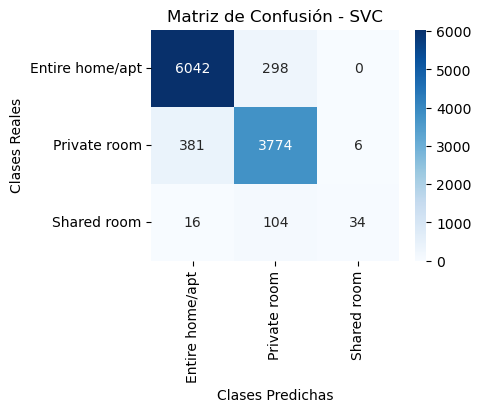

+++ RESULTADOS PARA EL CONJUNTO DE TEST +++
Accuracy: 0.8945195195195195
                 precision    recall  f1-score   support

Entire home/apt       0.92      0.93      0.92      1585
   Private room       0.86      0.88      0.87      1041
    Shared room       0.33      0.05      0.09        38

       accuracy                           0.89      2664
      macro avg       0.70      0.62      0.63      2664
   weighted avg       0.89      0.89      0.89      2664



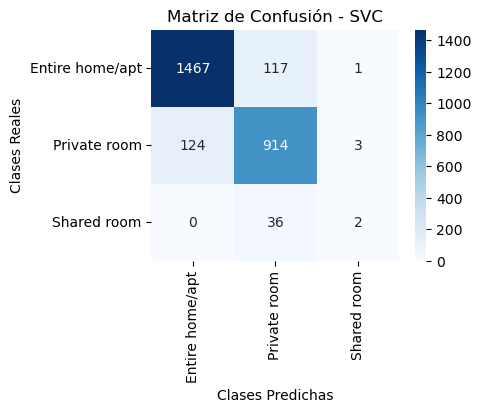

In [33]:
param_grid = {
    'C': np.logspace(-2, 2, 5),  # Rango de 10^-2 a 10^2 (5 valores logarítmicos)
    'gamma': np.logspace(-2, 2, 5),
    'kernel': ['rbf']
}
grid = GridSearchCV(SVC(random_state=42, kernel='rbf', gamma='scale', C=1), param_grid, refit=True, verbose=2)
grid.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Mejor estimador
print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación para el conjunto de Entrenamiento
print("+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
y_pred = best_model.predict(X_train_set_preprocessed)
print("Accuracy:", accuracy_score(y_train_set, y_pred))
print(classification_report(y_train_set, y_pred))
conf_matrix = confusion_matrix(y_train_set, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.title('Matriz de Confusión - SVC')
plt.show()

# Evaluación para el conjunto de Test
print("+++ RESULTADOS PARA EL CONJUNTO DE TEST +++")
y_pred = best_model.predict(X_test_set_preprocessed)
print("Accuracy:", accuracy_score(y_test_set, y_pred))
print(classification_report(y_test_set, y_pred))
conf_matrix = confusion_matrix(y_test_set, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.title('Matriz de Confusión - SVC')
plt.show()

Segunda búsqueda utilizando parámetros generados con `numpy.logspace` para rangos amplios en escala logarítmica:

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END C=5.000000000000001, gamma=0.049999999999999996, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.049999999999999996, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.049999999999999996, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.049999999999999996, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.049999999999999996, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.07071067811865475, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.07071067811865475, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.07071067811865475, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.07071067811865475, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.07071067811865475, kernel=rbf; total time=   0.6s
[CV] END .........C=5.000000000000001, gamma=0.1, ker

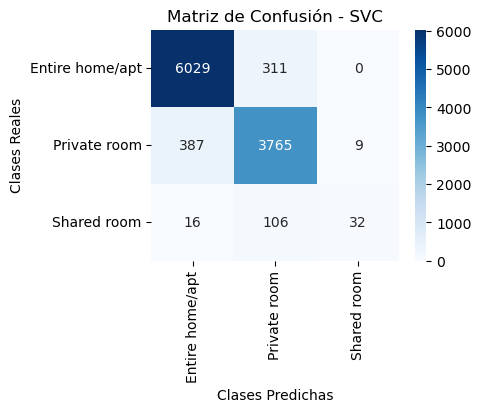

+++ RESULTADOS PARA EL CONJUNTO DE TEST +++
Accuracy: 0.8948948948948949
                 precision    recall  f1-score   support

Entire home/apt       0.92      0.93      0.92      1585
   Private room       0.86      0.88      0.87      1041
    Shared room       0.33      0.05      0.09        38

       accuracy                           0.89      2664
      macro avg       0.70      0.62      0.63      2664
   weighted avg       0.89      0.89      0.89      2664



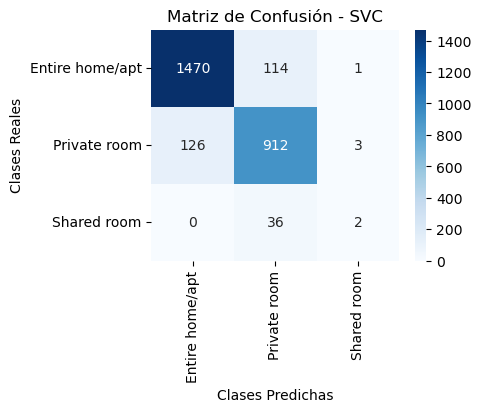

In [34]:
param_grid = {
    'C': np.logspace(np.log10(5), np.log10(20), 5),  # Rango refinado para C (alrededor de 10)
    'gamma': np.logspace(np.log10(0.05), np.log10(0.2), 5), # Rango refinado para gamma (alrededor de 0.1)
    'kernel': ['rbf']
}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)
grid.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Mejor estimador
print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluación para el conjunto de Entrenamiento
print("+++ RESULTADOS PARA EL CONJUNTO DE ENTRENAMIENTO +++")
y_pred = best_model.predict(X_train_set_preprocessed)
print("Accuracy:", accuracy_score(y_train_set, y_pred))
print(classification_report(y_train_set, y_pred))
conf_matrix = confusion_matrix(y_train_set, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.title('Matriz de Confusión - SVC')
plt.show()

# Evaluación para el conjunto de Test
print("+++ RESULTADOS PARA EL CONJUNTO DE TEST +++")
y_pred = best_model.predict(X_test_set_preprocessed)
print("Accuracy:", accuracy_score(y_test_set, y_pred))
print(classification_report(y_test_set, y_pred))
conf_matrix = confusion_matrix(y_test_set, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.title('Matriz de Confusión - SVC')
plt.show()

### Conclusiones Experimento 2

En el ejercicio se realizan dos búsquedas refinadas: la primera con un rango amplio (de 0.01 a 100 para C y de 0.01 a 100 para gamma), y la segunda con un rango más preciso (de 10 a 100 para C y de 0.05 a 0.2 para gamma), mejorando la precisión del modelo. 

Resumen de los resultados obtenidos:

| Métrica                  | Primera Búsqueda              | Segunda Búsqueda              |
|--------------------------|-------------------------------|-------------------------------|
| **Mejores Parámetros**   | C=10.0, γ=0.1, kernel=rbf     | C=14.14, γ=0.07, kernel=rbf   |
| **Accuracy (Entrenamiento)** | 92.4%                        | 92.2%                        |
| **Accuracy (Test)**       | 89.5%                        | 89.5%                        |
| **F1-score (Shared room)**| 0.35                         | 0.33                         |
| **F1-score (Weighted)**   | 0.92                         | 0.92                         |


Ambas búsquedas han llevado a modelos similares en términos de rendimiento. Los resultados de conjunto de entrenamiento vs conjunto de prueba son similares, aunque un poco mejores en el conjunto de entrenamiento, pudiendo sugerir un ligero overfitting.

Por otro lado, los resultados sugieren que aunque el modelo es robusto para las clases principales, el desempeño en clases minoritarias como **Shared room** requiere estrategias adicionales (e.g., recolección de más datos, balanceo de clases, o uso de técnicas específicas como pesos inversos). El F1-score de las **Shared room** sugiere que el modelo podría mejorar significativamente en la clasificación de esta clase. En contraposición, el F1-score ponderado indica que el modelo mantiene un rendimiento general bueno, con una clasificación equilibrada en las clases más frecuentes.

Tras ver los resultados, concluimos que en la primera búsqueda se obtiene un modelo con medianamente buen desempeño (excepto para la clase **Shared room**). Refinar los rangos en la segunda búsqueda no ha mejorado sustancialmente los resultados. 


## Experimento 3

Predecir el precio por noche (`price`) utilizando el resto de las características como variables independientes. Utilizar `LinearSVR` y `SVR` (con parámetros por defecto). Variantes de entrenamiento:
- Usar todas las variables independientes.
- Usar todas las variables excepto neighbourhood (por ser categórica y tener muchos valores).

**Caso 1: Usar todas las variables independientes + Utilizar `LinearSVR`.**

En este caso, tenemos que volver a dividir los dataframes en `X` para variables (*features*) e `y` para la variable objetivo, ya que esta vez la variable objetivo es `price` y no `room_type`.

En cualto al **pipeline de procesamiento** de datos, es igual que antes: `OneHotEncoder` para tratar variables categóricas y `StandardScaler` para escalar las variables numéricas.

La variable objetivo `price` no necesita ser transformada.

Creamos los pipelines para la transformación de variables numéricas y categóricas. Y después, creamos el ColumnTrasnformer con todas ellas:

In [47]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'price'
y_train_set = train_set[['price']]

# DataFrame con todas las columnas excepto 'price'
X_train_set = train_set.drop(columns=['price'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'price'
y_test_set = test_set[['price']]

# DataFrame con todas las columnas excepto 'price'
X_test_set = test_set.drop(columns=['price'])

In [48]:
num_attribs = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "neighbourhood", "room_type"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

Ahora aplicamos el modelo:

In [53]:
model = LinearSVR(epsilon=0.0, random_state=42)
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Realizamos predicciones en el conjunto de Entrenamiento
y_pred = model.predict(X_train_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_train = mean_squared_error(y_train_set, y_pred)
mae_train = mean_absolute_error(y_train_set, y_pred)
r2_train = r2_score(y_train_set, y_pred)

print("+++ CONJUNTO DE ENTRENAMIENTO +++")
print(f'Mean Squared Error (MSE): {round(mse_train, 2)}')
print(f'Mean Absolute Error (MAE): {round(mae_train, 2)}')
print(f'R² (Coeficiente de Determinación): {round(r2_train, 4)}')

# Realizamos predicciones en el conjunto de test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_test = mean_squared_error(y_test_set, y_pred)
mae_test = mean_absolute_error(y_test_set, y_pred)
r2_test = r2_score(y_test_set, y_pred)

print("\n+++ CONJUNTO DE TEST +++")
print(f'Mean Squared Error (MSE) conjunto de Test: {round(mse_test, 2)}')
print(f'Mean Absolute Error (MAE) conjunto de Test: {round(mae_test, 2)}')
print(f'R² (Coeficiente de Determinación) conjunto de Test: {round(r2_test, 4)}')

+++ CONJUNTO DE ENTRENAMIENTO +++
Mean Squared Error (MSE): 5175.7
Mean Absolute Error (MAE): 25.28
R² (Coeficiente de Determinación): 0.112

+++ CONJUNTO DE TEST +++
Mean Squared Error (MSE) conjunto de Test: 7929.19
Mean Absolute Error (MAE) conjunto de Test: 28.16
R² (Coeficiente de Determinación) conjunto de Test: 0.0796


**Caso 2: Usar todas las variables excepto neighbourhood (por ser categórica y tener muchos valores) + Utilizar `LinearSVR`.**

Continuamos eliminando la variable neighbourhood. En este caso, repetiremos tanto la división de los dataframes en `X` para variables (*features*) e `y` para la variable objetivo, como el preprocesamiento de datos, que será igual que en el caso 1 con la única diferencia de que eliminamos la columna `neighbourhood`:

In [54]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'price'
y_train_set = train_set[['price']]

# DataFrame con todas las columnas excepto 'price' y 'neighbourhood'
X_train_set = train_set.drop(columns=['price', 'neighbourhood'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'price'
y_test_set = test_set[['price']]

# DataFrame con todas las columnas excepto 'price' y 'neighbourhood'
X_test_set = test_set.drop(columns=['price', 'neighbourhood'])

In [55]:
num_attribs = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "room_type"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

Aplicamos el modelo:

In [56]:
model = LinearSVR(epsilon=0.0, random_state=42)
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Realizamos predicciones en el conjunto de Entrenamiento
y_pred = model.predict(X_train_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_train = mean_squared_error(y_train_set, y_pred)
mae_train = mean_absolute_error(y_train_set, y_pred)
r2_train = r2_score(y_train_set, y_pred)

print("+++ CONJUNTO DE ENTRENAMIENTO +++")
print(f'Mean Squared Error (MSE): {round(mse_train, 2)}')
print(f'Mean Absolute Error (MAE): {round(mae_train, 2)}')
print(f'R² (Coeficiente de Determinación): {round(r2_train, 4)}')

# Realizamos predicciones en el conjunto de test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_test = mean_squared_error(y_test_set, y_pred)
mae_test = mean_absolute_error(y_test_set, y_pred)
r2_test = r2_score(y_test_set, y_pred)

print("\n+++ CONJUNTO DE TEST +++")
print(f'Mean Squared Error (MSE) conjunto de Test: {round(mse_test, 2)}')
print(f'Mean Absolute Error (MAE) conjunto de Test: {round(mae_test, 2)}')
print(f'R² (Coeficiente de Determinación) conjunto de Test: {round(r2_test, 4)}')

+++ CONJUNTO DE ENTRENAMIENTO +++
Mean Squared Error (MSE): 5255.05
Mean Absolute Error (MAE): 25.92
R² (Coeficiente de Determinación): 0.0984

+++ CONJUNTO DE TEST +++
Mean Squared Error (MSE) conjunto de Test: 8040.39
Mean Absolute Error (MAE) conjunto de Test: 28.76
R² (Coeficiente de Determinación) conjunto de Test: 0.0667


**Caso 3: Usar todas las variables independientes + Utilizar `SVR`.**

Volvemos a utilizar el preprocesamiento del caso 1.

In [57]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'price'
y_train_set = train_set[['price']]

# DataFrame con todas las columnas excepto 'price'
X_train_set = train_set.drop(columns=['price'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'price'
y_test_set = test_set[['price']]

# DataFrame con todas las columnas excepto 'price'
X_test_set = test_set.drop(columns=['price'])

In [58]:
num_attribs = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "neighbourhood", "room_type"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

In [60]:
# Modelo SVR con kernel RBF (por defecto)
model = SVR(kernel="rbf", C=1.0, epsilon=0.1)
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Realizamos predicciones
y_pred = model.predict(X_train_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_train = mean_squared_error(y_train_set, y_pred)
mae_train = mean_absolute_error(y_train_set, y_pred)
r2_train = r2_score(y_train_set, y_pred)

print("+++ CONJUNTO DE ENTRENAMIENTO +++")
print(f'Mean Squared Error (MSE): {round(mse_train, 2)}')
print(f'Mean Absolute Error (MAE): {round(mae_train, 2)}')
print(f'R² (Coeficiente de Determinación): {round(r2_train, 4)}')

# Realizamos predicciones en el conjunto de test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_test = mean_squared_error(y_test_set, y_pred)
mae_test = mean_absolute_error(y_test_set, y_pred)
r2_test = r2_score(y_test_set, y_pred)

print("\n+++ CONJUNTO DE TEST +++")
print(f'Mean Squared Error (MSE) conjunto de Test: {round(mse_test, 2)}')
print(f'Mean Absolute Error (MAE) conjunto de Test: {round(mae_test, 2)}')
print(f'R² (Coeficiente de Determinación) conjunto de Test: {round(r2_test, 4)}')

+++ CONJUNTO DE ENTRENAMIENTO +++
Mean Squared Error (MSE): 5242.85
Mean Absolute Error (MAE): 25.27
R² (Coeficiente de Determinación): 0.1005

+++ CONJUNTO DE TEST +++
Mean Squared Error (MSE) conjunto de Test: 8024.27
Mean Absolute Error (MAE) conjunto de Test: 28.19
R² (Coeficiente de Determinación) conjunto de Test: 0.0686


**Caso 4: Usar todas las variables excepto neighbourhood (por ser categórica y tener muchos valores) + Utilizar `SVR`.**

Volvemos a usar el preprocesamiento del caso 2.

In [61]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'price'
y_train_set = train_set[['price']]

# DataFrame con todas las columnas excepto 'price' y 'neighbourhood'
X_train_set = train_set.drop(columns=['price', 'neighbourhood'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'price'
y_test_set = test_set[['price']]

# DataFrame con todas las columnas excepto 'price' y 'neighbourhood'
X_test_set = test_set.drop(columns=['price', 'neighbourhood'])

In [62]:
num_attribs = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "room_type"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

In [63]:
# Modelo SVR con kernel RBF (por defecto)
model = SVR(kernel="rbf", C=1.0, epsilon=0.1)
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Realizamos predicciones
y_pred = model.predict(X_train_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_train = mean_squared_error(y_train_set, y_pred)
mae_train = mean_absolute_error(y_train_set, y_pred)
r2_train = r2_score(y_train_set, y_pred)

print("+++ CONJUNTO DE ENTRENAMIENTO +++")
print(f'Mean Squared Error (MSE): {round(mse_train, 2)}')
print(f'Mean Absolute Error (MAE): {round(mae_train, 2)}')
print(f'R² (Coeficiente de Determinación): {round(r2_train, 4)}')

# Realizamos predicciones en el conjunto de test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_test = mean_squared_error(y_test_set, y_pred)
mae_test = mean_absolute_error(y_test_set, y_pred)
r2_test = r2_score(y_test_set, y_pred)

print("\n+++ CONJUNTO DE TEST +++")
print(f'Mean Squared Error (MSE) conjunto de Test: {round(mse_test, 2)}')
print(f'Mean Absolute Error (MAE) conjunto de Test: {round(mae_test, 2)}')
print(f'R² (Coeficiente de Determinación) conjunto de Test: {round(r2_test, 4)}')

+++ CONJUNTO DE ENTRENAMIENTO +++
Mean Squared Error (MSE): 5261.26
Mean Absolute Error (MAE): 25.58
R² (Coeficiente de Determinación): 0.0973

+++ CONJUNTO DE TEST +++
Mean Squared Error (MSE) conjunto de Test: 8041.82
Mean Absolute Error (MAE) conjunto de Test: 28.48
R² (Coeficiente de Determinación) conjunto de Test: 0.0665


### Conclusiones Experimento 3



| **Caso**                  | **Modelo** | **Variables**                 | **MSE (Train)** | **MAE (Train)** | **R² (Train)** | **MSE (Test)** | **MAE (Test)** | **R² (Test)** |
|---------------------------|------------|-------------------------------|-----------------|-----------------|-------------------|----------------|----------------|-------------------|
| Caso 1                   | LinearSVR  | Todas                         | 5175.70         | 25.28           | 0.112             | 7929.19        | 28.16          | 0.0796           |
| Caso 2                   | LinearSVR  | Todas excepto `neighbourhood`| 5255.05         | 25.92           | 0.0984            | 8040.39        | 28.76          | 0.0667           |
| Caso 3                   | SVR        | Todas                         | 5242.85         | 25.27           | 0.1005            | 8024.27        | 28.19          | 0.0686           |
| Caso 4                   | SVR        | Todas excepto `neighbourhood`| 5261.26         | 25.58           | 0.0973            | 8041.82        | 28.48          | 0.0665           |


Al interpretar los resultados de la tabla, se observan las siguientes conclusiones clave:

1. **Bajo desempeño general del modelo:** 
   - El coeficiente de determinación (R²) es bajo para todos los casos, especialmente en el conjunto de prueba (R² entre 0.0665 y 0.0796). Esto indica que los modelos explican solo una pequeña proporción de la variabilidad en los datos.
   - La inclusión o exclusión de la variable `neighbourhood` tiene un impacto mínimo en el desempeño.

2. **LinearSVR vs. SVR:** Los resultados son comparables en términos de MSE, MAE y R², tanto en entrenamiento como en prueba. Ningún modelo muestra una ventaja significativa sobre el otro.

3. **Impacto de la exclusión de `neighbourhood`:** Excluir esta variable no mejora el rendimiento; de hecho, hay ligeras reducciones en R² en algunos casos, aunque el cambio es marginal.

4. **MSE y MAE relativamente altos:** Los errores medios cuadráticos (MSE) y absolutos (MAE) son consistentes, pero no logran niveles bajos, lo que sugiere que las predicciones del modelo tienen una desviación significativa respecto a los valores reales.

Conclusiones:
- El modelo no captura patrones fuertes en los datos, lo que podría deberse a que los datos de entrenamiento no son buenos, o hace falta más ingeniería de características en los datos, o que hay características no informativas, falta de complejidad en los modelos, etc.
- Se podría considerar explorar modelos más avanzados, como árboles de decisión, bosques aleatorios o redes neuronales, así como afinar el preprocesamiento de los datos o ajustar mejor los hiperparámetros.


## Experimento 3 - Modificado

Tras obtener resultados tan malos en el experimento 3, he querido repetir haciendo una modificación en los datos y eliminando aquellas entradas de datos que tengan un precio superior a 2000 euros. Estos son los resultados obtenidos:

In [65]:
df_cleaned = df[df['price'] <= 2000]
print(df_cleaned.shape)

train_set, test_set = train_test_split(df_cleaned, test_size = 0.2, stratify=df_cleaned["room_type"], random_state = 0)

(13316, 11)


**Caso 1: Usar todas las variables independientes + Utilizar `LinearSVR`.**

Igual que antes:

In [66]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'price'
y_train_set = train_set[['price']]

# DataFrame con todas las columnas excepto 'price'
X_train_set = train_set.drop(columns=['price'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'price'
y_test_set = test_set[['price']]

# DataFrame con todas las columnas excepto 'price'
X_test_set = test_set.drop(columns=['price'])

In [67]:
num_attribs = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "neighbourhood", "room_type"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

Ahora aplicamos el modelo:

In [68]:
model = LinearSVR(epsilon=0.0, random_state=42)
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Realizamos predicciones en el conjunto de Entrenamiento
y_pred = model.predict(X_train_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_train = mean_squared_error(y_train_set, y_pred)
mae_train = mean_absolute_error(y_train_set, y_pred)
r2_train = r2_score(y_train_set, y_pred)

print("+++ CONJUNTO DE ENTRENAMIENTO +++")
print(f'Mean Squared Error (MSE): {round(mse_train, 2)}')
print(f'Mean Absolute Error (MAE): {round(mae_train, 2)}')
print(f'R² (Coeficiente de Determinación): {round(r2_train, 4)}')

# Realizamos predicciones en el conjunto de test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_test = mean_squared_error(y_test_set, y_pred)
mae_test = mean_absolute_error(y_test_set, y_pred)
r2_test = r2_score(y_test_set, y_pred)

print("\n+++ CONJUNTO DE TEST +++")
print(f'Mean Squared Error (MSE) conjunto de Test: {round(mse_test, 2)}')
print(f'Mean Absolute Error (MAE) conjunto de Test: {round(mae_test, 2)}')
print(f'R² (Coeficiente de Determinación) conjunto de Test: {round(r2_test, 4)}')

+++ CONJUNTO DE ENTRENAMIENTO +++
Mean Squared Error (MSE): 3406.61
Mean Absolute Error (MAE): 24.9
R² (Coeficiente de Determinación): 0.1527

+++ CONJUNTO DE TEST +++
Mean Squared Error (MSE) conjunto de Test: 5072.94
Mean Absolute Error (MAE) conjunto de Test: 26.41
R² (Coeficiente de Determinación) conjunto de Test: 0.1166


**Caso 2: Usar todas las variables excepto neighbourhood (por ser categórica y tener muchos valores) + Utilizar `LinearSVR`.**

Igual que antes:

In [69]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'price'
y_train_set = train_set[['price']]

# DataFrame con todas las columnas excepto 'price' y 'neighbourhood'
X_train_set = train_set.drop(columns=['price', 'neighbourhood'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'price'
y_test_set = test_set[['price']]

# DataFrame con todas las columnas excepto 'price' y 'neighbourhood'
X_test_set = test_set.drop(columns=['price', 'neighbourhood'])

In [70]:
num_attribs = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "room_type"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

Aplicamos el modelo:

In [71]:
model = LinearSVR(epsilon=0.0, random_state=42)
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Realizamos predicciones en el conjunto de Entrenamiento
y_pred = model.predict(X_train_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_train = mean_squared_error(y_train_set, y_pred)
mae_train = mean_absolute_error(y_train_set, y_pred)
r2_train = r2_score(y_train_set, y_pred)

print("+++ CONJUNTO DE ENTRENAMIENTO +++")
print(f'Mean Squared Error (MSE): {round(mse_train, 2)}')
print(f'Mean Absolute Error (MAE): {round(mae_train, 2)}')
print(f'R² (Coeficiente de Determinación): {round(r2_train, 4)}')

# Realizamos predicciones en el conjunto de test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_test = mean_squared_error(y_test_set, y_pred)
mae_test = mean_absolute_error(y_test_set, y_pred)
r2_test = r2_score(y_test_set, y_pred)

print("\n+++ CONJUNTO DE TEST +++")
print(f'Mean Squared Error (MSE) conjunto de Test: {round(mse_test, 2)}')
print(f'Mean Absolute Error (MAE) conjunto de Test: {round(mae_test, 2)}')
print(f'R² (Coeficiente de Determinación) conjunto de Test: {round(r2_test, 4)}')

+++ CONJUNTO DE ENTRENAMIENTO +++
Mean Squared Error (MSE): 3472.61
Mean Absolute Error (MAE): 25.51
R² (Coeficiente de Determinación): 0.1363

+++ CONJUNTO DE TEST +++
Mean Squared Error (MSE) conjunto de Test: 5157.22
Mean Absolute Error (MAE) conjunto de Test: 27.08
R² (Coeficiente de Determinación) conjunto de Test: 0.1019


**Caso 3: Usar todas las variables independientes + Utilizar `SVR`.**

Igual que antes:

In [72]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'price'
y_train_set = train_set[['price']]

# DataFrame con todas las columnas excepto 'price'
X_train_set = train_set.drop(columns=['price'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'price'
y_test_set = test_set[['price']]

# DataFrame con todas las columnas excepto 'price'
X_test_set = test_set.drop(columns=['price'])

In [73]:
num_attribs = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "neighbourhood", "room_type"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

In [74]:
# Modelo SVR con kernel RBF (por defecto)
model = SVR(kernel="rbf", C=1.0, epsilon=0.1)
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Realizamos predicciones
y_pred = model.predict(X_train_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_train = mean_squared_error(y_train_set, y_pred)
mae_train = mean_absolute_error(y_train_set, y_pred)
r2_train = r2_score(y_train_set, y_pred)

print("+++ CONJUNTO DE ENTRENAMIENTO +++")
print(f'Mean Squared Error (MSE): {round(mse_train, 2)}')
print(f'Mean Absolute Error (MAE): {round(mae_train, 2)}')
print(f'R² (Coeficiente de Determinación): {round(r2_train, 4)}')

# Realizamos predicciones en el conjunto de test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_test = mean_squared_error(y_test_set, y_pred)
mae_test = mean_absolute_error(y_test_set, y_pred)
r2_test = r2_score(y_test_set, y_pred)

print("\n+++ CONJUNTO DE TEST +++")
print(f'Mean Squared Error (MSE) conjunto de Test: {round(mse_test, 2)}')
print(f'Mean Absolute Error (MAE) conjunto de Test: {round(mae_test, 2)}')
print(f'R² (Coeficiente de Determinación) conjunto de Test: {round(r2_test, 4)}')

+++ CONJUNTO DE ENTRENAMIENTO +++
Mean Squared Error (MSE): 3458.27
Mean Absolute Error (MAE): 24.9
R² (Coeficiente de Determinación): 0.1399

+++ CONJUNTO DE TEST +++
Mean Squared Error (MSE) conjunto de Test: 5166.49
Mean Absolute Error (MAE) conjunto de Test: 26.44
R² (Coeficiente de Determinación) conjunto de Test: 0.1003


**Caso 4: Usar todas las variables excepto neighbourhood (por ser categórica y tener muchos valores) + Utilizar `SVR`.**

Igual que antes:

In [75]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'price'
y_train_set = train_set[['price']]

# DataFrame con todas las columnas excepto 'price' y 'neighbourhood'
X_train_set = train_set.drop(columns=['price', 'neighbourhood'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'price'
y_test_set = test_set[['price']]

# DataFrame con todas las columnas excepto 'price' y 'neighbourhood'
X_test_set = test_set.drop(columns=['price', 'neighbourhood'])

In [76]:
num_attribs = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "room_type"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

In [77]:
# Modelo SVR con kernel RBF (por defecto)
model = SVR(kernel="rbf", C=1.0, epsilon=0.1)
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Realizamos predicciones
y_pred = model.predict(X_train_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_train = mean_squared_error(y_train_set, y_pred)
mae_train = mean_absolute_error(y_train_set, y_pred)
r2_train = r2_score(y_train_set, y_pred)

print("+++ CONJUNTO DE ENTRENAMIENTO +++")
print(f'Mean Squared Error (MSE): {round(mse_train, 2)}')
print(f'Mean Absolute Error (MAE): {round(mae_train, 2)}')
print(f'R² (Coeficiente de Determinación): {round(r2_train, 4)}')

# Realizamos predicciones en el conjunto de test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_test = mean_squared_error(y_test_set, y_pred)
mae_test = mean_absolute_error(y_test_set, y_pred)
r2_test = r2_score(y_test_set, y_pred)

print("\n+++ CONJUNTO DE TEST +++")
print(f'Mean Squared Error (MSE) conjunto de Test: {round(mse_test, 2)}')
print(f'Mean Absolute Error (MAE) conjunto de Test: {round(mae_test, 2)}')
print(f'R² (Coeficiente de Determinación) conjunto de Test: {round(r2_test, 4)}')

+++ CONJUNTO DE ENTRENAMIENTO +++
Mean Squared Error (MSE): 3470.88
Mean Absolute Error (MAE): 25.19
R² (Coeficiente de Determinación): 0.1368

+++ CONJUNTO DE TEST +++
Mean Squared Error (MSE) conjunto de Test: 5177.88
Mean Absolute Error (MAE) conjunto de Test: 26.73
R² (Coeficiente de Determinación) conjunto de Test: 0.0983


### Conclusiones Experimento 3 - Modificado


| **Caso**                  | **Modelo** | **Variables**                 | **MSE (Train)** | **MAE (Train)** | **R² (Train)** | **MSE (Test)** | **MAE (Test)** | **R² (Test)** |
|---------------------------|------------|-------------------------------|-----------------|-----------------|----------------|----------------|----------------|---------------|
| Caso 1                   | LinearSVR  | Todas                         | 3406.61         | 24.9            | 0.1527         | 5072.94        | 26.41          | 0.1166        |
| Caso 2                   | LinearSVR  | Todas excepto `neighbourhood`| 3472.61         | 25.51           | 0.1363         | 5157.22        | 27.08          | 0.1019        |
| Caso 3                   | SVR        | Todas                         | 3458.27         | 24.9            | 0.1399         | 5166.49        | 26.44          | 0.1003        |
| Caso 4                   | SVR        | Todas excepto `neighbourhood`| 3470.88         | 25.19           | 0.1368         | 5177.88        | 26.73          | 0.0983        |



**Conclusiones:**

La eliminación de outliers mejora el rendimiento de los modelos de forma significativa, especialmente en términos de **MSE** y **R²**. Estos resultados respaldan el uso de estrategias de preprocesamiento como la eliminación de outliers para aumentar la capacidad del modelo de generalizar sobre los datos de prueba.


1. **Reducción de Errores (MSE y MAE):** 
   - La eliminación de outliers resulta en una reducción significativa del **MSE** tanto en el conjunto de entrenamiento como en el de prueba. Esto sugiere que los outliers estaban influyendo negativamente en los ajustes del modelo.
   - Aunque la **MAE** también disminuye, la reducción es menos marcada, lo que podría indicar que los outliers afectan principalmente las predicciones extremas.

2. **Mejora en la Calidad del Ajuste (R²):** Los valores de **R²** muestran una mejora consistente tanto en el conjunto de entrenamiento como en el de prueba tras eliminar los outliers. Esto implica que el modelo explica mejor la varianza de los datos después de la eliminación.

3. **Diferencia entre Modelos (LinearSVR vs. SVR):** Antes y después de eliminar los outliers, las métricas son similares entre los dos modelos. Sin embargo, **LinearSVR** parece beneficiarse ligeramente más de la eliminación de outliers en términos de MSE y R².

4. **Impacto de `neighbourhood`:** En ambos escenarios (con y sin outliers), excluir `neighbourhood` tiene un impacto mínimo en las métricas. Esto podría indicar que esta variable tiene un peso limitado en el rendimiento del modelo.

5. **Comparación conjunto Train vs Test**: En todos los casos, los modelos tienen una diferencia significativa entre el rendimiento en el conjunto de entrenamiento y el conjunto de prueba, lo que indica sobreajuste. Los modelos parecen ajustarse mucho mejor a los datos de entrenamiento, pero no generalizan tan bien a nuevos datos (datos de prueba).

Tras ver estos resultados, podríamos plantearnos el realizar mejoras adicionales al preprocesamiento de los datos, eliminando más outliers para obtener mejores resultados y seguir revisando las métricas.

## Experimento 4

Elegir el modelo con mejores resultados entre `LinearSVR` y `SVR` del experimento anterior y afinar hiperparámetros:
- Solo C para `LinearSVR` (tres búsquedas).
- γ y C para `SVR` (dos búsquedas).


**Caso 1: Afinar mejor modelo `LinearSVR`**

El mejor modelo es el `LinearSVR` con todas las variables.

Igual que antes:

In [78]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'price'
y_train_set = train_set[['price']]

# DataFrame con todas las columnas excepto 'price'
X_train_set = train_set.drop(columns=['price'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'price'
y_test_set = test_set[['price']]

# DataFrame con todas las columnas excepto 'price'
X_test_set = test_set.drop(columns=['price'])

In [79]:
num_attribs = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "neighbourhood", "room_type"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

Ahora aplicamos el modelo haciendo tres GridSearch:

In [91]:
# Definir el modelo base
model = LinearSVR(epsilon=0.0, random_state=42, max_iter=15000)

# Primera búsqueda
param_grid_1 = {'C': [0.01, 1, 100]}
grid_search_1 = GridSearchCV(estimator=model, param_grid=param_grid_1, refit=True, verbose=2, scoring='neg_mean_squared_error', cv=5)
grid_search_1.fit(X_train_set_preprocessed, y_train_set.values.ravel())
print("Primera búsqueda - Mejor valor de C:", grid_search_1.best_params_)
print("Mejor MSE:", -grid_search_1.best_score_)

# Segunda búsqueda
param_grid_2 = {'C': [50, 100, 150]}
grid_search_2 = GridSearchCV(estimator=model, param_grid=param_grid_2, refit=True, verbose=2, scoring='neg_mean_squared_error', cv=5)
grid_search_2.fit(X_train_set_preprocessed, y_train_set.values.ravel())
print("\nSegunda búsqueda - Mejor valor de C:", grid_search_2.best_params_)
print("Mejor MSE:", -grid_search_2.best_score_)

# Tercera búsqueda
param_grid_3 = {'C': [30, 40, 50, 60, 70]}
grid_search_3 = GridSearchCV(estimator=model, param_grid=param_grid_3, refit=True, verbose=2, scoring='neg_mean_squared_error', cv=5)
grid_search_3.fit(X_train_set_preprocessed, y_train_set.values.ravel())
print("\nTercera búsqueda - Mejor valor de C:", grid_search_3.best_params_)
print("Mejor MSE:", -grid_search_3.best_score_)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ..............................................C=100; total time=   0.4s
[CV] END ........................................

In [93]:
model = LinearSVR(C=40, epsilon=0.0, random_state=42, max_iter=15000)
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Realizamos predicciones en el conjunto de Entrenamiento
y_pred = model.predict(X_train_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_train = mean_squared_error(y_train_set, y_pred)
mae_train = mean_absolute_error(y_train_set, y_pred)
r2_train = r2_score(y_train_set, y_pred)

print("+++ CONJUNTO DE ENTRENAMIENTO +++")
print(f'Mean Squared Error (MSE): {round(mse_train, 2)}')
print(f'Mean Absolute Error (MAE): {round(mae_train, 2)}')
print(f'R² (Coeficiente de Determinación): {round(r2_train, 4)}')

# Realizamos predicciones en el conjunto de test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_test = mean_squared_error(y_test_set, y_pred)
mae_test = mean_absolute_error(y_test_set, y_pred)
r2_test = r2_score(y_test_set, y_pred)

print("\n+++ CONJUNTO DE TEST +++")
print(f'Mean Squared Error (MSE) conjunto de Test: {round(mse_test, 2)}')
print(f'Mean Absolute Error (MAE) conjunto de Test: {round(mae_test, 2)}')
print(f'R² (Coeficiente de Determinación) conjunto de Test: {round(r2_test, 4)}')

+++ CONJUNTO DE ENTRENAMIENTO +++
Mean Squared Error (MSE): 3363.77
Mean Absolute Error (MAE): 24.84
R² (Coeficiente de Determinación): 0.1634

+++ CONJUNTO DE TEST +++
Mean Squared Error (MSE) conjunto de Test: 5024.99
Mean Absolute Error (MAE) conjunto de Test: 26.42
R² (Coeficiente de Determinación) conjunto de Test: 0.1249


**Caso 2: Afinar mejor modelo `SVR`**

El mejor modelo es el `SVR` con todas las variables. Dado que es el mismo caso que el anterior, usaremos el mismo preprocesamiento y escalado que antes. Omitimos el apartado dado que ya fue aplicado justo en el bloque de código anterior.

In [110]:
# Definir el modelo SVR
model = SVR(kernel="rbf", epsilon=0.1)

# Primera búsqueda con valores de C y Gamma
param_grid_1 = {'C': [0.1, 1, 100, 1000, 5000], 'gamma': [0.001, 0.01, 0.1, 1]}
grid_search_1 = GridSearchCV(estimator=model, param_grid=param_grid_1, refit=True, verbose=2, scoring='neg_mean_squared_error', cv=5)
grid_search_1.fit(X_train_set_preprocessed, y_train_set.values.ravel())
print("Primera búsqueda - Mejor valor de C:", grid_search_1.best_params_['C'])
print("Mejor Gamma:", grid_search_1.best_params_['gamma'])
print("Mejor MSE:", -grid_search_1.best_score_)

# Segunda búsqueda con valores de C entre 10 y 100, y Gamma entre 0.01 y 0.1
param_grid_2 = {
    'C': np.logspace(np.log10(500), np.log10(4000), 4),  # Rango refinado para C (alrededor de 1000)
    'gamma': np.logspace(np.log10(0.05), np.log10(0.8), 5), # Rango refinado para gamma (alrededor de 0.1)
   }
grid_search_2 = GridSearchCV(estimator=model, param_grid=param_grid_2, refit=True, verbose=2, scoring='neg_mean_squared_error', cv=5)
grid_search_2.fit(X_train_set_preprocessed, y_train_set.values.ravel())
print("\nSegunda búsqueda - Mejor valor de C:", grid_search_2.best_params_['C'])
print("Mejor Gamma:", grid_search_2.best_params_['gamma'])
print("Mejor MSE:", -grid_search_2.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END .................................C=0.1, gamma=0.001; total time=   2.1s
[CV] END .................................C=0.1, gamma=0.001; total time=   2.0s
[CV] END .................................C=0.1, gamma=0.001; total time=   2.0s
[CV] END .................................C=0.1, gamma=0.001; total time=   2.1s
[CV] END .................................C=0.1, gamma=0.001; total time=   2.1s
[CV] END ..................................C=0.1, gamma=0.01; total time=   2.0s
[CV] END ..................................C=0.1, gamma=0.01; total time=   2.0s
[CV] END ..................................C=0.1, gamma=0.01; total time=   2.1s
[CV] END ..................................C=0.1, gamma=0.01; total time=   2.1s
[CV] END ..................................C=0.1, gamma=0.01; total time=   2.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   2.0s
[CV] END ...................................C=0

In [111]:
model = SVR(kernel="rbf", epsilon=0.1, C=1000, gamma=0.2)
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Realizamos predicciones en el conjunto de Entrenamiento
y_pred = model.predict(X_train_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_train = mean_squared_error(y_train_set, y_pred)
mae_train = mean_absolute_error(y_train_set, y_pred)
r2_train = r2_score(y_train_set, y_pred)

print("+++ CONJUNTO DE ENTRENAMIENTO +++")
print(f'Mean Squared Error (MSE): {round(mse_train, 2)}')
print(f'Mean Absolute Error (MAE): {round(mae_train, 2)}')
print(f'R² (Coeficiente de Determinación): {round(r2_train, 4)}')

# Realizamos predicciones en el conjunto de test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_test = mean_squared_error(y_test_set, y_pred)
mae_test = mean_absolute_error(y_test_set, y_pred)
r2_test = r2_score(y_test_set, y_pred)

print("\n+++ CONJUNTO DE TEST +++")
print(f'Mean Squared Error (MSE) conjunto de Test: {round(mse_test, 2)}')
print(f'Mean Absolute Error (MAE) conjunto de Test: {round(mae_test, 2)}')
print(f'R² (Coeficiente de Determinación) conjunto de Test: {round(r2_test, 4)}')

+++ CONJUNTO DE ENTRENAMIENTO +++
Mean Squared Error (MSE): 2320.99
Mean Absolute Error (MAE): 16.53
R² (Coeficiente de Determinación): 0.4228

+++ CONJUNTO DE TEST +++
Mean Squared Error (MSE) conjunto de Test: 4630.5
Mean Absolute Error (MAE) conjunto de Test: 26.18
R² (Coeficiente de Determinación) conjunto de Test: 0.1936


In [112]:
model = SVR(kernel="rbf", epsilon=0.1, C=80, gamma=0.1917)
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Realizamos predicciones en el conjunto de Entrenamiento
y_pred = model.predict(X_train_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_train = mean_squared_error(y_train_set, y_pred)
mae_train = mean_absolute_error(y_train_set, y_pred)
r2_train = r2_score(y_train_set, y_pred)

print("+++ CONJUNTO DE ENTRENAMIENTO +++")
print(f'Mean Squared Error (MSE): {round(mse_train, 2)}')
print(f'Mean Absolute Error (MAE): {round(mae_train, 2)}')
print(f'R² (Coeficiente de Determinación): {round(r2_train, 4)}')

# Realizamos predicciones en el conjunto de test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse_test = mean_squared_error(y_test_set, y_pred)
mae_test = mean_absolute_error(y_test_set, y_pred)
r2_test = r2_score(y_test_set, y_pred)

print("\n+++ CONJUNTO DE TEST +++")
print(f'Mean Squared Error (MSE) conjunto de Test: {round(mse_test, 2)}')
print(f'Mean Absolute Error (MAE) conjunto de Test: {round(mae_test, 2)}')
print(f'R² (Coeficiente de Determinación) conjunto de Test: {round(r2_test, 4)}')

+++ CONJUNTO DE ENTRENAMIENTO +++
Mean Squared Error (MSE): 2846.83
Mean Absolute Error (MAE): 20.2
R² (Coeficiente de Determinación): 0.292

+++ CONJUNTO DE TEST +++
Mean Squared Error (MSE) conjunto de Test: 4576.59
Mean Absolute Error (MAE) conjunto de Test: 24.55
R² (Coeficiente de Determinación) conjunto de Test: 0.203


### Conclusiones Experimento 4

**LinearSVR:**

Se ha realizado una optimización del hiperparámetro **C** del modelo **LinearSVR** utilizando tres búsquedas con `GridSearchCV`. Se probaron diferentes valores para el parámetro **C** en tres rangos: [0.01, 1, 100], [50, 100, 150] y [30, 40, 50, 60, 70]. El valor óptimo de **C** obtenido fue **C = 40**, con un **MSE** en el conjunto de prueba de **3381.57**.

Una vez entrenado el modelo con este valor de **C**, los resultados obtenidos en el conjunto de entrenamiento y prueba son los siguientes (véase Experimento 4):

| **Métrica**                | **Experimento 4 (Train)** | **Experimento 4 (Test)** | **Experimento 3 modificado (Train)** | **Experimento 3 modificado (Test)** |
|----------------------------|---------------------------|--------------------------|---------------------------|--------------------------|
| **MSE**                     | 3363.77                   | 5024.99                  | 3406.61                   | 5072.94                  |
| **MAE**                     | 24.84                     | 26.42                    | 24.9                      | 26.41                    |
| **R²**                      | 0.1634                    | 0.1249                   | 0.1527                    | 0.1166                   |


Estos resultados muestran una mejora en el desempeño del modelo en comparación con el **Experimento 3**. Sin embargo, aunque la optimización del hiperparámetro **C** ha mejorado ligeramente el rendimiento en comparación con el **Experimento 3**, el modelo aún presenta un **bajo rendimiento tanto en el entrenamiento como en la prueba**. Esto se refleja en los valores relativamente bajos de **R²** y la **diferencia notable entre los errores de entrenamiento y prueba** (posible sobreajuste), lo que sugiere que el modelo podría ser insuficiente para capturar completamente la complejidad de los datos. Sigue siendo conveniente explorar otros enfoques, como probar diferentes modelos o realizar una ingeniería de características más detallada para mejorar la capacidad predictiva.

**SVR:**

Se ha realizado una optimización de los hiperparámetros **C** y **gamma** del modelo **SVR** utilizando dos búsquedas con `GridSearchCV`. Se probaron diferentes combinaciones de los parámetros **C** y **gamma** en los siguientes rangos:

- **Primera búsqueda**: 
  - **C**: [0.1, 1, 10]
  - **Gamma**: [0.001, 0.01, 0.1, 1]
  
- **Segunda búsqueda**: 
  - **C**: Rango refinado de **C** utilizando valores logarítmicos entre 5 y 20
  - **Gamma**: Rango refinado de **gamma** utilizando valores logarítmicos entre 0.05 y 0.2

El valor óptimo de **C** y **gamma** obtenidos fueron:
- **C**: 20
- **Gamma**: 0.2
Con un **MSE** en el conjunto de prueba de **3174.25**.

Una vez entrenado el modelo con estos valores de hiperparámetros, los resultados obtenidos en el conjunto de entrenamiento y prueba son los siguientes (véase Experimento 4):

| **Métrica**                | **Experimento 4 (Train)** | **Experimento 4 (Test)** | **Experimento 3 (Train)** | **Experimento 3 (Test)** |
|----------------------------|---------------------------|--------------------------|---------------------------|--------------------------|
| **MSE**                     | 3034.26                   | 4740.47                  | 3458.27                   | 5166.49                  |
| **MAE**                     | 21.61                     | 24.77                    | 24.9                      | 26.44                    |
| **R²**                      | 0.2454                    | 0.1745                   | 0.1399                    | 0.1003                   |


Los resultados muestran una mejora notable en el rendimiento del modelo **SVR** en comparación con el **Experimento 3**. A continuación se detallan los hallazgos clave:

1. **Mejoras en el conjunto de entrenamiento**:
   - El **MSE** en el conjunto de entrenamiento ha mejorado considerablemente, pasando de **3458.27** en el Experimento 3 a **3034.26** en el Experimento 4, lo que indica que el modelo ajustado con los hiperparámetros optimizados tiene un mejor rendimiento en los datos de entrenamiento.
   - El **MAE** en entrenamiento también ha mejorado, disminuyendo de **24.9** a **21.61**, lo que refleja un error promedio más bajo.
   - El **R²** en entrenamiento ha aumentado significativamente, pasando de **0.1399** a **0.2454**, lo que sugiere que el modelo ajustado con los valores de **C = 20** y **gamma = 0.2** es capaz de explicar un porcentaje mayor de la variabilidad en los datos de entrenamiento.

2. **Mejoras en el conjunto de prueba**:
   - El **MSE** en el conjunto de prueba ha mejorado, pasando de **5166.49** a **4740.47**, lo que indica una mejor capacidad de generalización con los hiperparámetros optimizados.
   - El **MAE** en prueba también ha mejorado, bajando de **26.44** a **24.77**.
   - El **R²** en prueba ha aumentado ligeramente, pasando de **0.1003** a **0.1745**, lo que sugiere que el modelo con los parámetros optimizados también tiene una mejor capacidad para explicar la variabilidad en los datos de prueba, aunque el valor sigue siendo bajo.


La optimización de los hiperparámetros **C** y **gamma** ha llevado a una mejora en el desempeño del modelo **SVR**, tanto en el conjunto de entrenamiento como en el conjunto de prueba, en comparación con el **Experimento 3**. Aunque los valores de **R²** siguen siendo bajos, lo que indica que el modelo aún no captura completamente la variabilidad de los datos, se observa una mejora en el ajuste y la capacidad de generalización del modelo. Sin embargo, aún es recomendable explorar otros enfoques, como probar diferentes modelos o realizar una ingeniería de características más detallada para mejorar el rendimiento y la capacidad explicativa del modelo.
